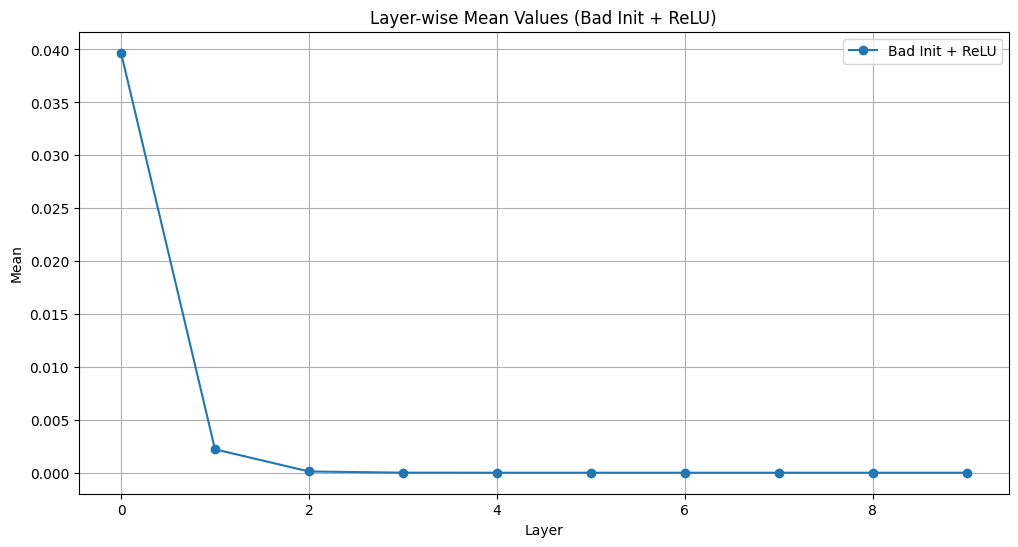

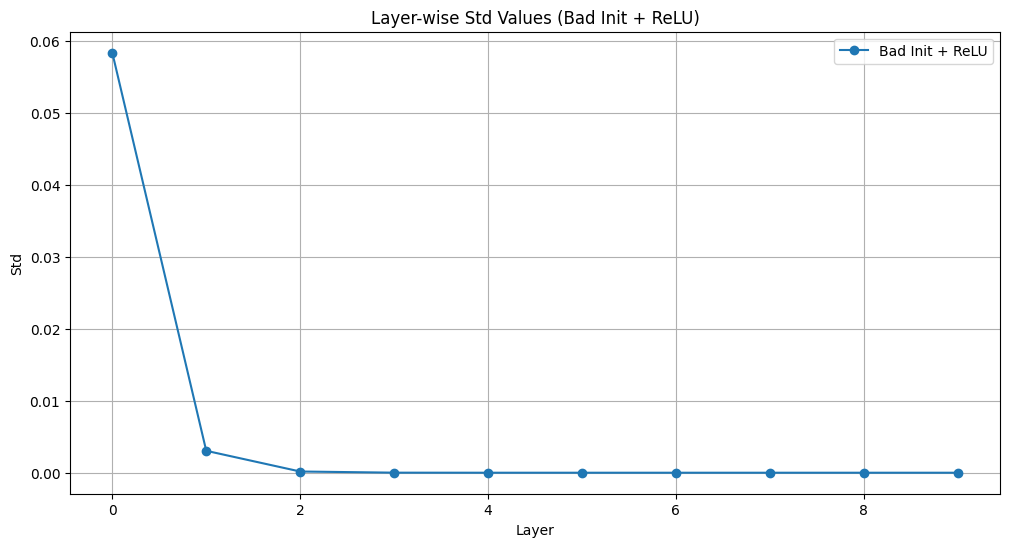

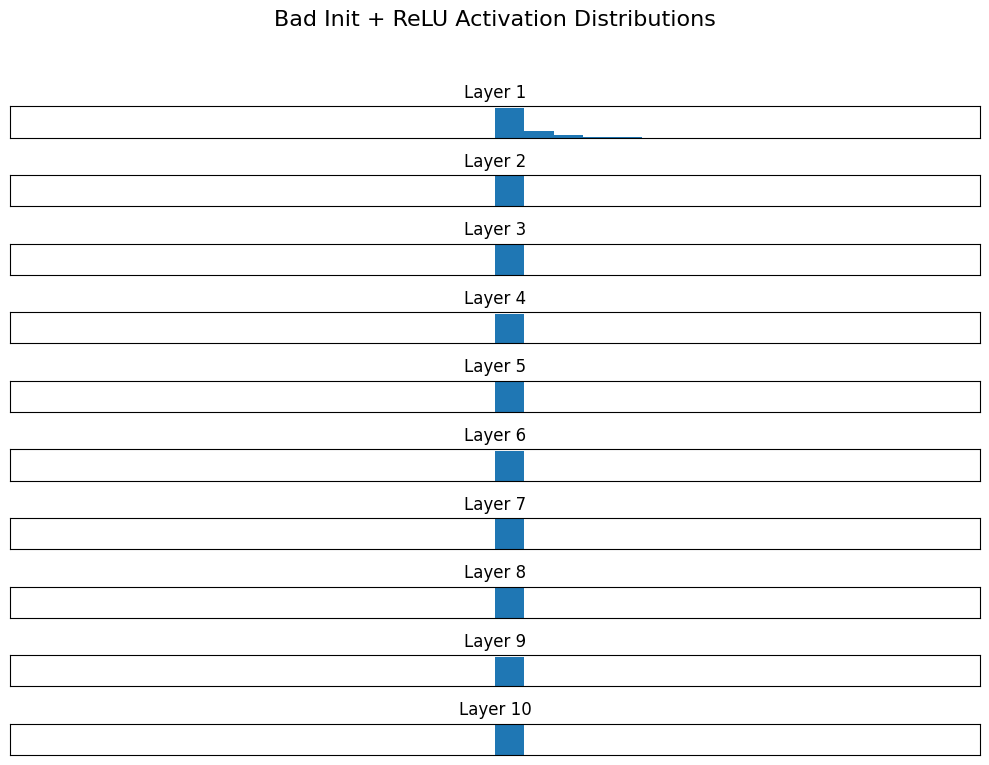

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Common settings
N, D = 1000, 100  # Number of samples and input size
hidden_layer_sizes = [50] * 10  # 10 layers, each with 50 neurons
np.random.seed(42)  # For reproducibility

# Activation and Initialization functions
def relu(x): return np.maximum(0, x)  # ReLU activation function
def bad_init(fan_in, fan_out): return np.random.randn(fan_in, fan_out) * 0.01  # Bad initialization function (very small weights)

# Experiment setup
exp_name = 'Bad Init + ReLU'  # Experiment name
act = relu  # Chosen activation function
init = bad_init  # Chosen initialization method

# Run the model
X = np.random.randn(N, D)  # Input data (randomly generated)
Hs = {}  # Dictionary to store activations of each layer

# Forward pass through the layers
for i in range(len(hidden_layer_sizes)):
    fan_in = X.shape[1]  # Number of input features
    fan_out = hidden_layer_sizes[i]  # Number of neurons in this layer
    W = init(fan_in, fan_out)  # Bad initialization for weights
    H = X @ W  # Matrix multiplication (X * W)
    H = act(H)  # Apply ReLU activation function
    Hs[i] = H  # Store the activations
    X = H  # Set the output of this layer as input for the next layer

# Calculate mean and standard deviation for each layer's activations
means = [np.mean(H) for H in Hs.values()]
stds = [np.std(H) for H in Hs.values()]

# 1. Plotting the Mean and Standard Deviation
# Mean values across layers
plt.figure(figsize=(12, 6))
plt.plot(range(len(means)), means, marker='o', linestyle='-', label=exp_name)
plt.title('Layer-wise Mean Values (Bad Init + ReLU)')
plt.xlabel('Layer')
plt.ylabel('Mean')
plt.grid(True)
plt.legend()
plt.show()

# Standard deviation values across layers
plt.figure(figsize=(12, 6))
plt.plot(range(len(stds)), stds, marker='o', linestyle='-', label=exp_name)
plt.title('Layer-wise Std Values (Bad Init + ReLU)')
plt.xlabel('Layer')
plt.ylabel('Std')
plt.grid(True)
plt.legend()
plt.show()

# 2. Histogram: Distribution of activations across layers
plt.figure(figsize=(10, 8))
for i, H in Hs.items():
    plt.subplot(len(Hs), 1, i + 1)  # Plot each layer's activation distribution
    plt.hist(H.ravel(), bins=30, range=(-1, 1))  # Flatten the activation matrix and plot histogram
    plt.title(f"Layer {i+1}")  # Label each subplot
    plt.xticks([])  # Remove x-axis ticks
    plt.yticks([])  # Remove y-axis ticks

# Add a main title for the histograms
plt.suptitle(f'{exp_name} Activation Distributions', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Make room for the main title
plt.show()
